# MC-Match
### MC-Match helps the user to find a motorcycle that fits their needs and budget, as well as helping to predict the price on a motorcycle the user already owns. 
## EDA 

here we will evaluate the dataset and filter out the actual data we want to use

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv('dataset/motorcycles_clean.csv')

In [63]:
df.head()

,Company,Country of Origin,Model,Number of cc,Horsepower,Torque,Transmission Type,Drivetrain,Number of Seating,Year,Looks,Body Type,Engine Type,Number of Cylinders,Price (SEK)
0,Aprilia,Italy,RS 660,659.0,100.0,67.0,Manual,Chain,2,2021,Sport,Naked/Street,Parallel-twin,2.0,120890.0
1,Aprilia,Italy,Tuono 660,659.0,100.0,67.0,Manual,Chain,2,2021,Sport,Naked/Street,Parallel-twin,2.0,131890.0
2,Aprilia,Italy,RS 125,124.9,15.0,12.0,Manual,Chain,2,2022,Sport,Sport,Single-cylinder,1.0,49390.0
3,Aprilia,Italy,Shiver 900,896.0,95.0,90.0,Manual,Shaft Drive,2,2022,Adventure,Naked/Street,V-twin,2.0,153890.0
4,Aprilia,Italy,Tuono 1100,1077.0,175.0,121.0,Manual,Shaft Drive,2,2022,Adventure,Naked/Street,V-twin,2.0,219890.0


In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 362 entries, 0 to 361
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              362 non-null    str    
 1   Country of Origin    362 non-null    str    
 2   Model                362 non-null    str    
 3   Number of cc         361 non-null    float64
 4   Horsepower           362 non-null    float64
 5   Torque               361 non-null    float64
 6   Transmission Type    362 non-null    str    
 7   Drivetrain           362 non-null    str    
 8   Number of Seating    362 non-null    int64  
 9   Year                 362 non-null    int64  
 10  Looks                362 non-null    str    
 11  Body Type            362 non-null    str    
 12  Engine Type          362 non-null    str    
 13  Number of Cylinders  360 non-null    float64
 14  Price (SEK)          362 non-null    float64
dtypes: float64(5), int64(2), str(8)
memory usage: 64.2 

In [65]:
df.isnull().sum()

Company                0
Country of Origin      0
Model                  0
Number of cc           1
Horsepower             0
Torque                 1
Transmission Type      0
Drivetrain             0
Number of Seating      0
Year                   0
Looks                  0
Body Type              0
Engine Type            0
Number of Cylinders    2
Price (SEK)            0
dtype: int64

In [66]:
df.dropna(inplace=True)

In [67]:
df.info()

<class 'pandas.DataFrame'>
Index: 358 entries, 0 to 361
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              358 non-null    str    
 1   Country of Origin    358 non-null    str    
 2   Model                358 non-null    str    
 3   Number of cc         358 non-null    float64
 4   Horsepower           358 non-null    float64
 5   Torque               358 non-null    float64
 6   Transmission Type    358 non-null    str    
 7   Drivetrain           358 non-null    str    
 8   Number of Seating    358 non-null    int64  
 9   Year                 358 non-null    int64  
 10  Looks                358 non-null    str    
 11  Body Type            358 non-null    str    
 12  Engine Type          358 non-null    str    
 13  Number of Cylinders  358 non-null    float64
 14  Price (SEK)          358 non-null    float64
dtypes: float64(5), int64(2), str(8)
memory usage: 66.5 KB


In [68]:
df.isnull().sum()

Company                0
Country of Origin      0
Model                  0
Number of cc           0
Horsepower             0
Torque                 0
Transmission Type      0
Drivetrain             0
Number of Seating      0
Year                   0
Looks                  0
Body Type              0
Engine Type            0
Number of Cylinders    0
Price (SEK)            0
dtype: int64

## Overview of numeric variables in the dataset

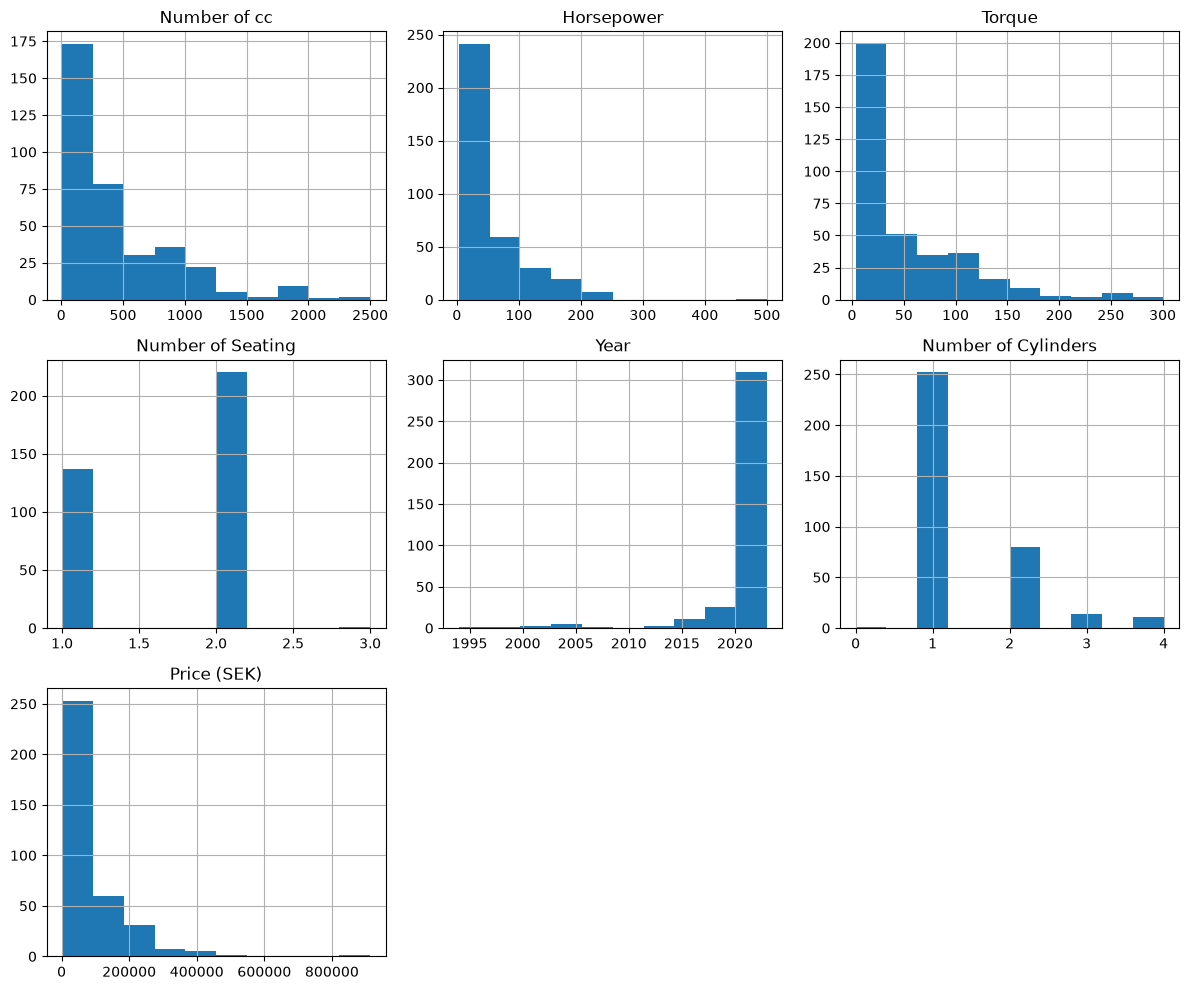

In [69]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

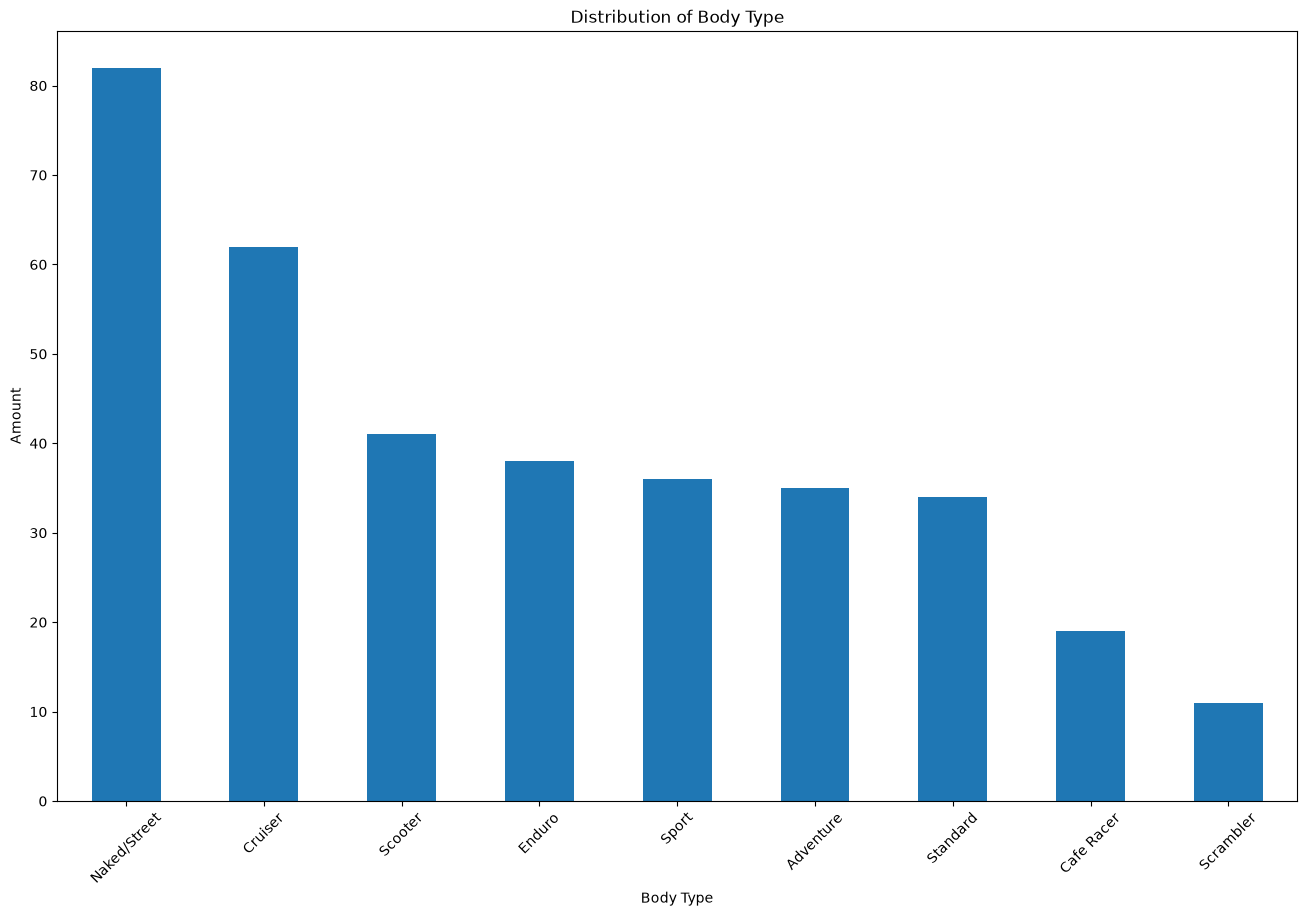

In [70]:
df['Body Type'].value_counts().plot(kind='bar', figsize=(16, 10))

plt.xlabel('Body Type')
plt.ylabel('Amount')
plt.title('Distribution of Body Type')
plt.xticks(rotation=45)
plt.show()


In [71]:
df['Body Type'].value_counts()


Body Type
Naked/Street    82
Cruiser         62
Scooter         41
Enduro          38
Sport           36
Adventure       35
Standard        34
Cafe Racer      19
Scrambler       11
Name: count, dtype: int64

===========================================================================================================================================
## Behind the curtens 
With help from the histogram we found some odd data in the dataset. 
- Some motorcycle had 900 cylinders which is impossible so we changed them to the correct amount. 
- We combined a lot of different body types into the bigger main groups that can be seen above. There were a lot of body type that represented the same type but with different names/casing. 
- The pricings was also in a differant value that we converted from INR to -> SEK. 
- We dropped the rows that had missing values. 

===========================================================================================================================================

## How's the price distrubuted in the dataset?


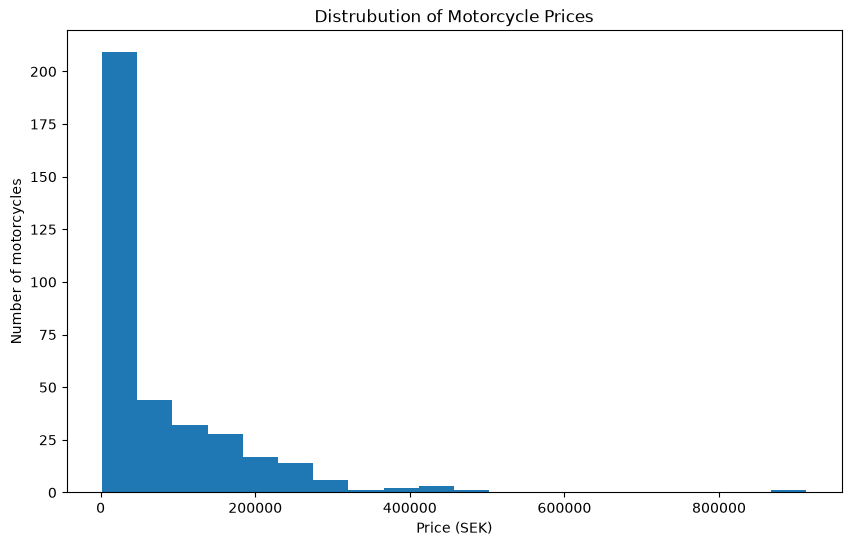

In [72]:
plt.figure(figsize=(10, 6))
plt.hist(df["Price (SEK)"], bins=20)

plt.xlabel("Price (SEK)")
plt.ylabel("Number of motorcycles")
plt.title("Distrubution of Motorcycle Prices")

plt.show()


C:\Users\halle\AppData\Local\Temp\ipykernel_9204\1933241096.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price (SEK)"], vert=False)


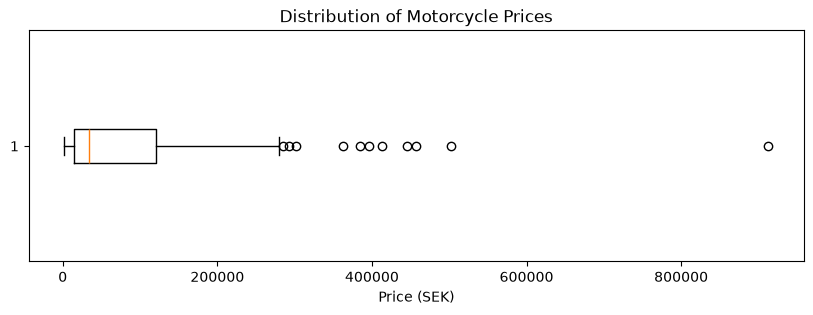

In [73]:
plt.figure(figsize=(10, 3))

plt.boxplot(df["Price (SEK)"], vert=False)

plt.xlabel("Price (SEK)")
plt.title("Distribution of Motorcycle Prices")

plt.show()

Most motorcycles are priced below 100,000 SEK. Most of the others are between 100,000 and 300,000 SEK, with a few around 400,000 SEK. There is also one motorcycle that stands out at around 900,000 SEK. Overall, the prices are mostly on the lower end, with a few much more expensive motorcycles.


## Price vs body type

<Figure size 1200x600 with 0 Axes>

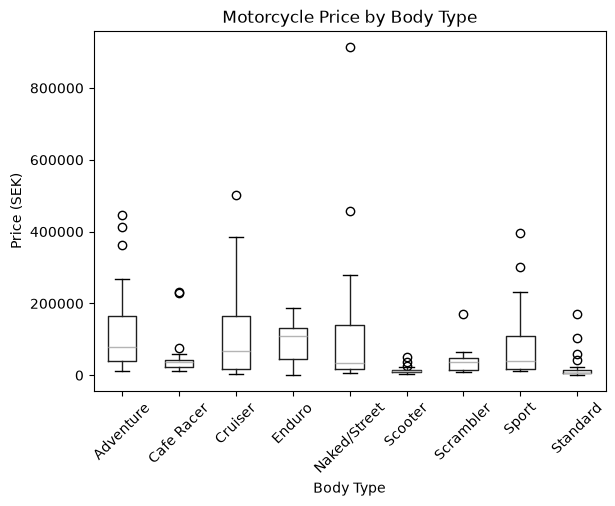

In [74]:
plt.figure(figsize=(12, 6))

df.boxplot(
    column="Price (SEK)",
    by="Body Type",
    grid=False
)

plt.xlabel("Body Type")
plt.ylabel("Price (SEK)")
plt.title("Motorcycle Price by Body Type")
plt.suptitle("")

plt.xticks(rotation=45)
plt.show()

Adventure and cruiser motorcycles generally have the highest prices, while scooters, cafe racers and scramblers are among the cheapest. Standard motorcycles have a relatively low median price but several expensive outliers. Sport and naked/street motorcycles also have some very high-priced outliers.


## 10 most expensive motorcycles in dataset

In [75]:
df.nlargest(10, "Price (SEK)")[["Company", "Model", "Price (SEK)"]]

,Company,Model,Price (SEK)
46,Confederate,X132 Hellcat Combat Fighter,913000.0
44,Confederate,Hellcat,502150.0
45,Confederate,Wraith,456500.0
58,Harley-Davidson,Road Glide Special,445390.0
59,Harley-Davidson,Naked/Street Glide Special,412390.0
125,Norton,V4SV,395890.0
182,Harley-Davidson,LiveWire,385000.0
124,Norton,Atlas,362890.0
51,Ducati,Panigale V4,301510.0
63,Harley-Davidson,Heritage Classic,292490.0


To get a better understanding of the highest-priced motorcycles in the dataset, we looked at the most expensive models and which companies they belong to. This also helps us identify which brands are positioned in the premium price range.


In [76]:
df.nlargest(10, "Horsepower")[["Company", "Model", "Price (SEK)", "Horsepower"]]

,Company,Model,Price (SEK),Horsepower
221,Triton Electric Bikes,Artemis,27500.0,500.0
222,Apollo,Artemis,16500.0,250.0
223,Hero Electric,Artemis,11000.0,250.0
224,Ampere,Artemis,8800.0,250.0
46,Confederate,X132 Hellcat Combat Fighter,913000.0,227.0
51,Ducati,Panigale V4,301510.0,221.0
118,MV Agusta,Brutale 1000 RR,279400.0,208.0
44,Confederate,Hellcat,502150.0,205.0
161,Yamaha,R1,220000.0,200.0
19,BMW,S 1000 RR,176000.0,199.0


## Korrelation between price and the numeric valuables

Number of cc: 0.68


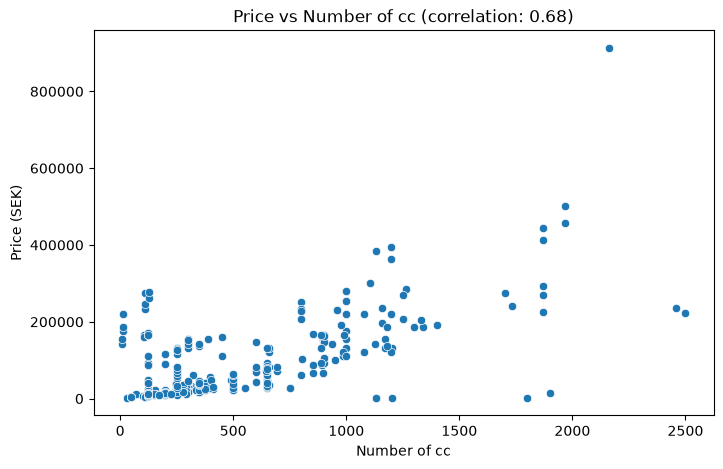

Horsepower: 0.63


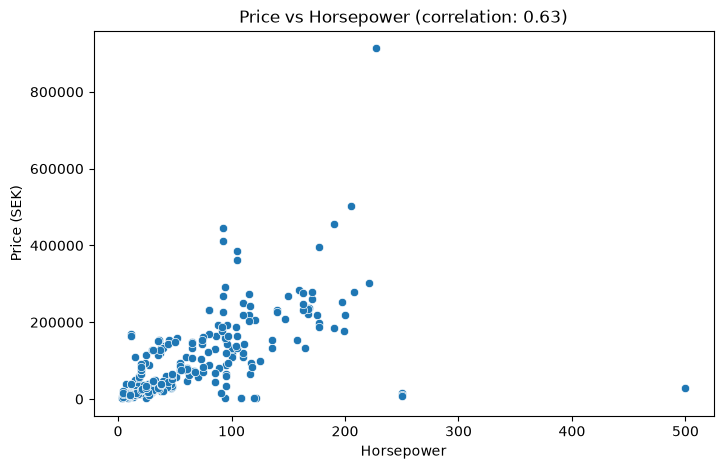

Torque: 0.69


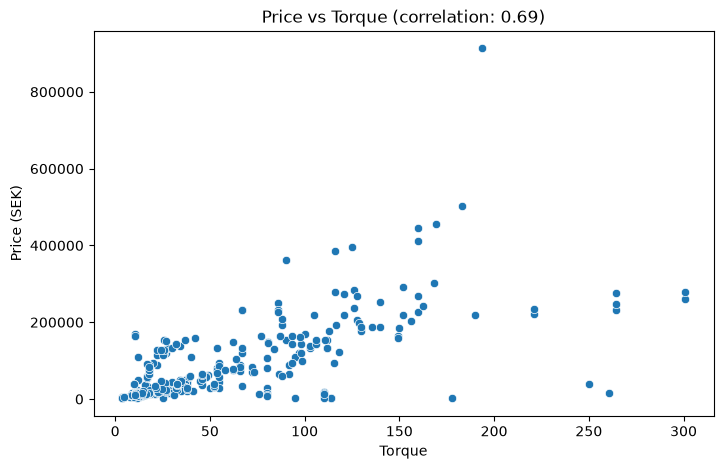

Year: -0.04


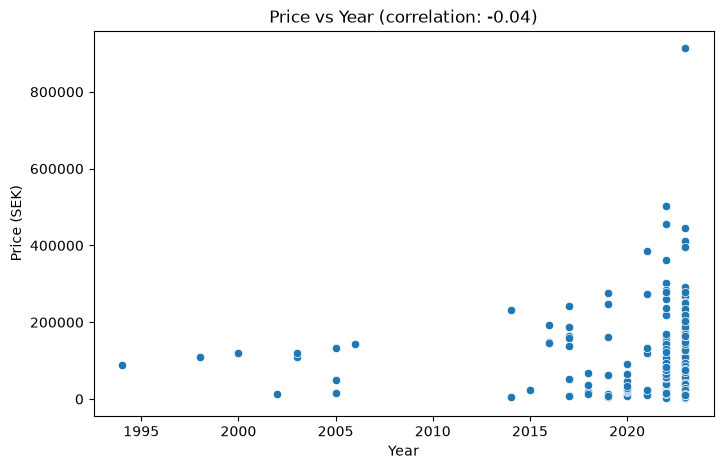

Number of Cylinders: 0.51


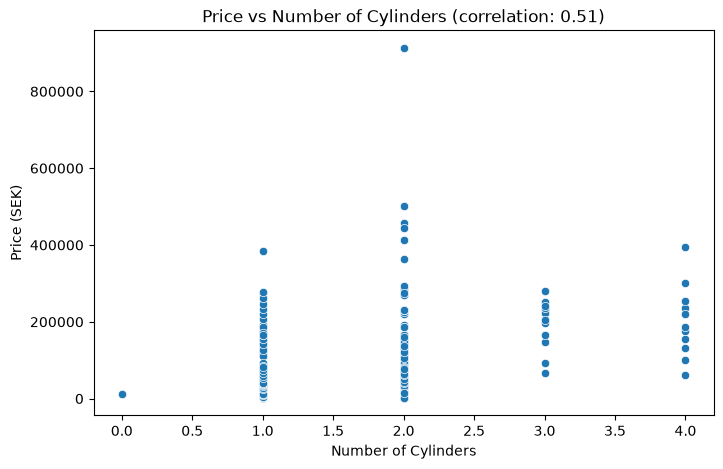

In [77]:
numeric_features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Number of Cylinders"
]


for feature in numeric_features:
    correlation = df[feature].corr(df["Price (SEK)"])

    print(f"{feature}: {correlation:.2f}")

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=feature, y="Price (SEK)")
    plt.title(f"Price vs {feature} (correlation: {correlation:.2f})")
    plt.xlabel(feature)
    plt.ylabel("Price (SEK)")
    plt.show()

There seems to be a general relationship between engine size and price. Motorcycles with higher engine sizes are generally more expensive, although there is quite a lot of variation between motorcycles with similar engine sizes. There are also a few very expensive outliers.

## Correlation matrix, numeric values and price 

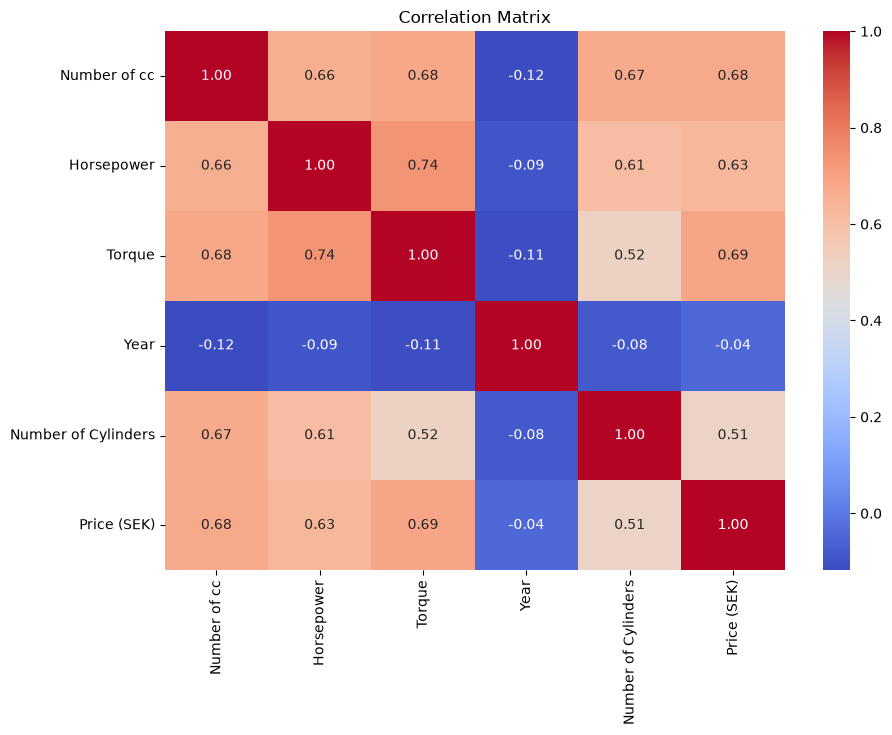

In [78]:
numeric_features_with_price = numeric_features + ["Price (SEK)"]

corr = df[numeric_features_with_price].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## What defines a Body Type?
### Body type vs technical features

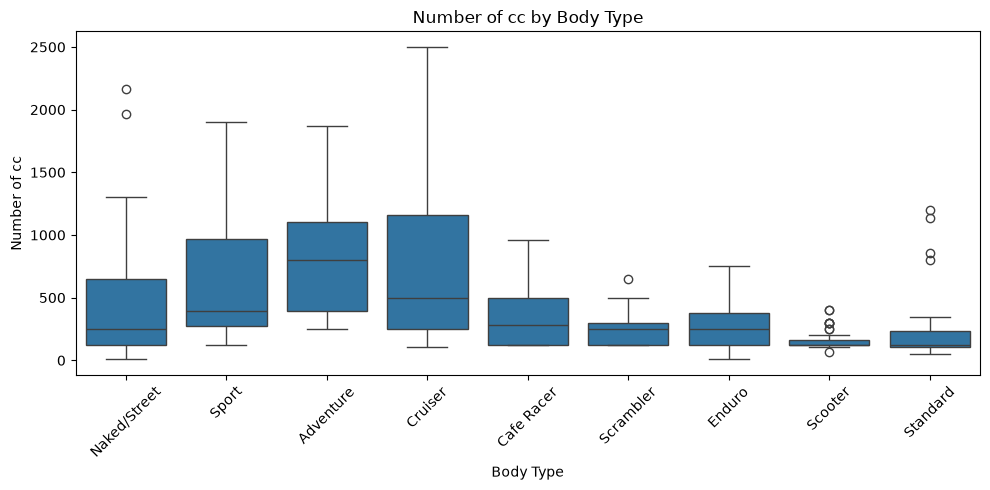

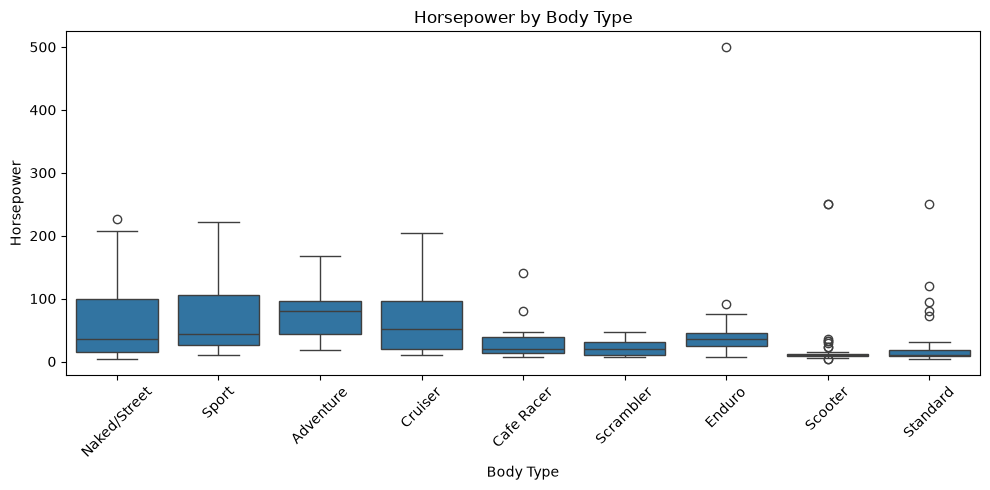

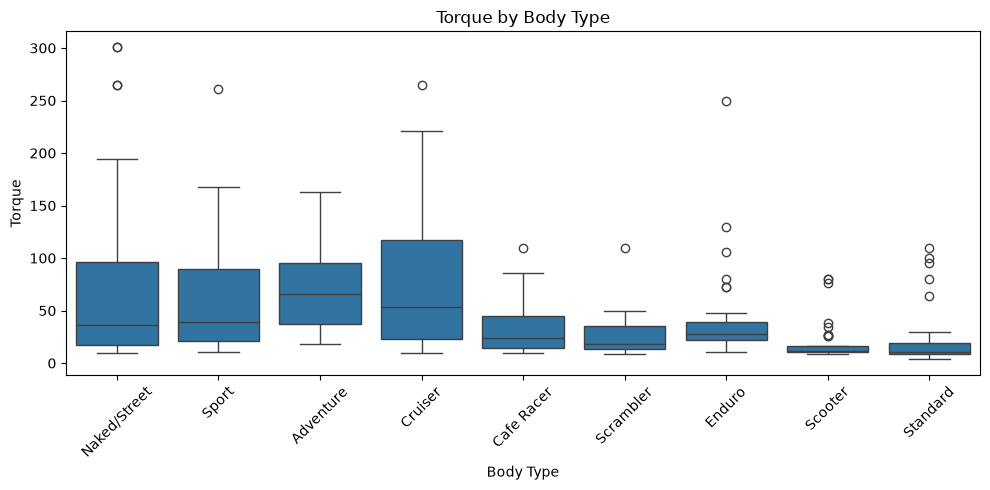

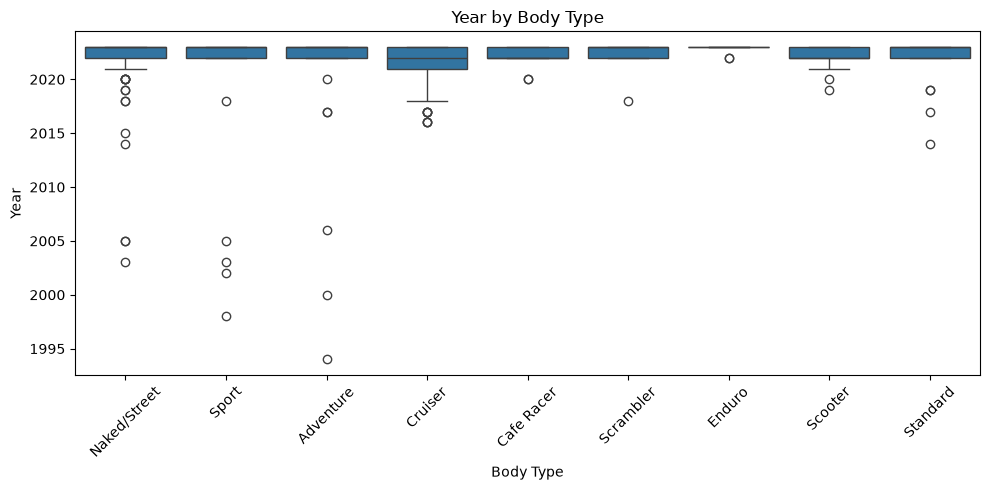

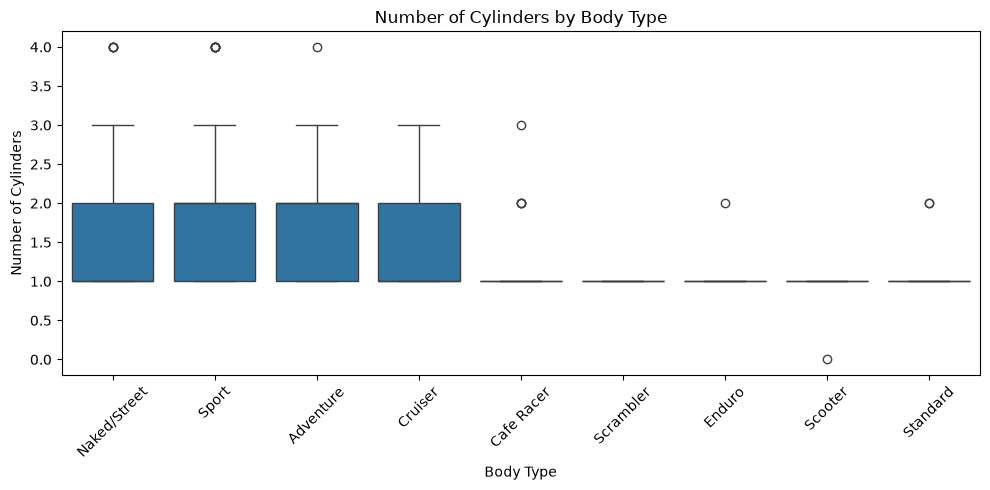

In [79]:
features = [
    "Number of cc",
    "Horsepower",
    "Torque",
    "Year",
    "Number of Cylinders"
]

for feature in features:
    plt.figure(figsize=(10, 5))
    
    sns.boxplot(
        data=df,
        x="Body Type",
        y=feature
    )
    
    plt.title(f"{feature} by Body Type")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### **CC vs. Body Type**
Cruiser motorcycles generally have the highest engine displacement (cc), followed by Adventure, Sport, and Naked/Street. However, Adventure has the highest median, meaning that the typical Adventure motorcycle in the dataset has a larger engine than the typical motorcycle in the other categories.

### **Horsepower vs. Body Type**
Adventure has the highest median horsepower, followed by Cruiser, Sport, and Naked/Street. Sport and Naked/Street motorcycles, however, have higher upper values, indicating that some models in these categories have very high horsepower. Overall, there is some variation between body types, although the distributions overlap considerably.

### **Torque vs. Body Type**
Adventure has the highest median torque, followed by Cruiser, while Naked/Street and Sport have similar median values. Cruiser has the highest upper values, indicating that some Cruiser motorcycles have particularly high torque. Overall, Adventure and Cruiser tend to have higher torque than Sport and Naked/Street.

### **Year vs. Body Type**
The model year shows relatively small differences between the body types, as most motorcycles in all categories are from 2020 or later. However, some older motorcycles are present, particularly in the Adventure, Sport, and Naked/Street categories. Adventure contains the oldest motorcycles in the dataset, with some models dating back to around 1994.

### **Number of Cylinders vs. Body Type**
Naked/Street, Sport, Adventure, and Cruiser have very similar distributions of the number of cylinders, with their boxes mainly ranging between one and two cylinders. The remaining body types are primarily represented by single-cylinder motorcycles. Therefore, the number of cylinders appears to have limited value for distinguishing between the main body types in this dataset.


In [80]:
body_type_mean = df.groupby("Body Type")[
    ["Number of cc", "Horsepower", "Torque", "Number of Seating", "Year", "Number of Cylinders"]
].mean().round(1)

body_type_mean

,Number of cc,Horsepower,Torque,Number of Seating,Year,Number of Cylinders
Body Type,,,,,,
Adventure,795.4,75.2,72.9,1.9,2020.3,1.7
Cafe Racer,369.0,33.8,35.0,1.5,2022.2,1.3
Cruiser,744.7,64.4,76.6,1.8,2021.5,1.5
Enduro,291.7,49.4,41.0,1.1,2022.9,1.0
Naked/Street,436.2,63.9,63.9,1.6,2021.4,1.5
Scooter,164.5,24.4,18.7,1.8,2022.3,1.0
Scrambler,272.4,22.4,30.5,1.6,2022.2,1.0
Sport,587.0,73.5,61.8,1.6,2020.4,2.0
Standard,243.7,28.1,23.4,1.5,2022.1,1.1


### Feature selection for motorcycle classification

Based on the exploratory analysis, some numerical variables appear to be more useful than others for distinguishing between motorcycle body types. Engine displacement (cc), horsepower, and torque show the clearest differences between the main body types. Adventure and Cruiser motorcycles generally have larger engine displacements and higher torque, while Sport motorcycles tend to have high horsepower and, on average, more cylinders. These variables therefore provide useful information about the characteristics of different motorcycle types.

The number of cylinders shows some differences between categories, but the distributions overlap considerably, particularly among Adventure, Cruiser, Sport, and Naked/Street motorcycles. Model year, on the other hand, shows very little difference between the body types, as most motorcycles in the dataset are from approximately the same period. We therefore expect year to be less useful for distinguishing between motorcycle types.

Based on these findings, **engine displacement, horsepower, and torque will be given particular focus during the classification modeling**, while number of cylinders and other available features will also be evaluated. Rather than deciding their importance solely from the exploratory analysis, the final feature importance will be determined by the classification models and their performance. This allows the model to identify which characteristics are most useful for categorizing motorcycles into the different types.


In [81]:
df["Looks"].value_counts()

Looks
Modern       97
Classic      87
Sport        57
Adventure    45
Retro        42
Urban         8
Off-road      8
Cruiser       7
Practical     7
Name: count, dtype: int64

In [82]:


df["Drivetrain"].value_counts()

Drivetrain
Chain          226
Automatic       53
Shaft Drive     27
Belt            26
Electric        19
Other            7
Name: count, dtype: int64

In [83]:
df["Transmission Type"].value_counts()

Transmission Type
Manual       266
Automatic     86
Electric       6
Name: count, dtype: int64

In [84]:
df["Engine Type"].value_counts()

Engine Type
Single-cylinder    135
Other               79
Parallel-twin       42
V-twin              35
Electric            31
single-cylinder     15
Inline-three        13
Boxer                3
Inline-four          3
V4                   2
Name: count, dtype: int64

In [86]:
df["Country of Origin"].value_counts()

Country of Origin
Italy          92
India          47
UK             44
China          42
USA            32
Japan          24
Taiwan         18
Austria        14
Sweden         12
Germany         8
Spain           8
France          8
South Korea     5
Canada          3
Denmark         1
Name: count, dtype: int64